<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/iLogos/nsst.jpg" width="400" height="100">

# DEMI | NOVA SST

## Mecânica dos Sólidos I

# III. Materiais elásticos
## Lei de Hooke. Parte II

## Problema 1 <a name="PIII71"></a>

Num elemento plano de madeira, em que as fibras fazem um ângulo de 20 graus com a vertical, estão aplicadas as seguintes tensões: Tensão vertical de compressão: 2 MPa; Tensão horizontal de compressão: 6 MPa; Tensão de corte: Variando entre 1 e -1 MPa.

[a)](#A) Calcule a maior tensão de corte que pode ocorrer, paralelamente às fibras.

[b)](#B) Calcule a extensão que seria lida, para o valor da tensão de corte da alínea a), ao longo das fibras do material.

[c)](#C) Calcule as tensões principais que ocorrem no material para uma tensão de corte de 1 MPa.

Assuma um comportamento isotrópico para o qual: $E = 7$ GPa e $\nu = $ 0.4.

In [53]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=5)

def mtensoes(sXX,sXY,sXZ,sYY,sYZ,sZZ): return np.array([[sXX,sXY,sXZ],[sXY,sYY,sYZ],[sYZ,sYZ,sZZ]])

tt0 = mtensoes(sxx,txy,0,syy,0,0)
print('matriz das tensões : \n',tt0,' [MPa]')

matriz das tensões : 
 [[-6 array([-1.00000e+00, -9.00000e-01, -8.00000e-01, -7.00000e-01,
            -6.00000e-01, -5.00000e-01, -4.00000e-01, -3.00000e-01,
            -2.00000e-01, -1.00000e-01, -2.22045e-16,  1.00000e-01,
             2.00000e-01,  3.00000e-01,  4.00000e-01,  5.00000e-01,
             6.00000e-01,  7.00000e-01,  8.00000e-01,  9.00000e-01,
             1.00000e+00])                                          0]
 [array([-1.00000e+00, -9.00000e-01, -8.00000e-01, -7.00000e-01,
         -6.00000e-01, -5.00000e-01, -4.00000e-01, -3.00000e-01,
         -2.00000e-01, -1.00000e-01, -2.22045e-16,  1.00000e-01,
          2.00000e-01,  3.00000e-01,  4.00000e-01,  5.00000e-01,
          6.00000e-01,  7.00000e-01,  8.00000e-01,  9.00000e-01,
          1.00000e+00])                                          -2 0]
 [0 0 0]]  [MPa]


/tmp/ipykernel_273117/2249826947.py:6: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  def mtensoes(sXX,sXY,sXZ,sYY,sYZ,sZZ): return np.array([[sXX,sXY,sXZ],[sXY,sYY,sYZ],[sYZ,sYZ,sZZ]])


In [54]:
def sxx1(sxx,syy,txy,t):
    return (sxx+syy)/2 + (sxx-syy)/2*np.cos(2*t) + txy*np.sin(2*t)

def syy1(sxx,syy,txy,t):
    return (sxx+syy)/2 - (sxx-syy)/2*np.cos(2*t) - txy*np.sin(2*t)

def txy1(sxx,syy,txy,t):
    return (syy-sxx)/2*np.sin(2*t) + txy*np.cos(2*t)

def angPrincipal(sxx,syy,txy):
    return np.arctan(2*txy/(sxx-syy))/2

def angShearMax(sxx,syy,sxy): return np.arctan(- (sxx-syy)/2/sxy )/2

print('\na.1) componentes matriz tensão = +1 MPa  --------------------------')
# Dados de entrada
sxx, syy, txy = -6., -2.,  1.
ang = 70. # unit: Deg

angt = np.arange(-90,160,1)
tsxx = sxx1(sxx,syy,txy,np.deg2rad(angt))
tsyy = syy1(sxx,syy,txy,np.deg2rad(angt))
ttxy = txy1(sxx,syy,txy,np.deg2rad(angt))

aprinc = np.rad2deg(angPrincipal(sxx,syy,txy))
print('angPrincipal (deg) =','{:.3f}'.format(aprinc))

tsxx1 = sxx1(sxx,syy,txy,np.deg2rad(aprinc))
tsyy1 = syy1(sxx,syy,txy,np.deg2rad(aprinc))
ttxy1 = txy1(sxx,syy,txy,np.deg2rad(aprinc))
print('tens. xx plano principal (MPa) =','{:.6f}'.format(tsxx1))
print('tens. yy plano principal (MPa) =','{:.6f}'.format(tsyy1))
print('tens. xy plano principal (MPa) =','{:.6f}'.format(ttxy1))

corteAngP1 = np.rad2deg(angShearMax(sxx,syy,txy)) + 90
tcortemax = txy1(sxx,syy,txy,np.deg2rad(corteAngP1))
print('ângulo de corte principal (deg) =','{:.3f}'.format(corteAngP1))
print('tens. corte máxima (MPa) =','{:.6f}'.format(tcortemax))

tsxxL1 = sxx1(sxx,syy,txy,np.deg2rad(ang))
tsyyL1 = syy1(sxx,syy,txy,np.deg2rad(ang))
ttxyL1 = txy1(sxx,syy,txy,np.deg2rad(ang))
print('\ntens. xx na direção das fibras (MPa) =','{:.6f}'.format(tsxxL1))
print('tens. yy na direção das fibras (MPa) =','{:.6f}'.format(tsyyL1))
print('tens. xy na direção das fibras (MPa) =','{:.6f}'.format(ttxyL1))


a.1) componentes matriz tensão = +1 MPa  --------------------------
angPrincipal (deg) = -13.283
tens. xx plano principal (MPa) = -6.236068
tens. yy plano principal (MPa) = -1.763932
tens. xy plano principal (MPa) = 0.000000
ângulo de corte principal (deg) = 121.717
tens. corte máxima (MPa) = -2.236068

tens. xx na direção das fibras (MPa) = -1.825124
tens. yy na direção das fibras (MPa) = -6.174876
tens. xy na direção das fibras (MPa) = 0.519531


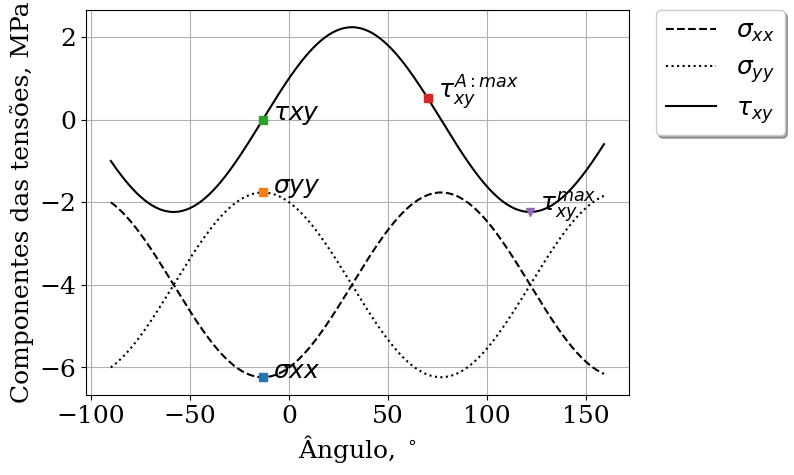

In [55]:
# use LaTeX fonts in the plot
plt.rc('text', usetex=False)
plt.rc('font', family='serif', size=18)

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(angt, tsxx, 'k--', label=r'$\sigma_{xx}$')
ax.plot(angt, tsyy, 'k:', label=r'$\sigma_{yy}$')
ax.plot(angt, ttxy, 'k', label=r'$\tau_{xy}$')
ax.plot(aprinc, tsxx1, 's')
ax.text(aprinc+5, tsxx1,r'$\sigma xx$')
ax.plot(aprinc, tsyy1, 's')
ax.text(aprinc+5, tsyy1,r'$\sigma yy$')
ax.plot(aprinc, ttxy1, 's')
ax.text(aprinc+5, ttxy1,r'$\tau xy$')

ax.plot(ang, ttxyL1, 's')
ax.text(ang+5, ttxyL1,r'$\tau_{xy}^{A:max}$')

ax.plot(corteAngP1, tcortemax, 'v')
ax.text(corteAngP1+5, tcortemax,r'$\tau_{xy}^{max}$')

ax.set(xlabel=r'Ângulo, $^\circ$', ylabel='Componentes das tensões, MPa')
legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., shadow=True, fontsize=18)
ax.grid()
plt.show()

In [56]:

print('\na.2) componentes matriz tensão = -1 MPa  --------------------------')
# Dados de entrada
txy = -1.

angt = np.arange(-10,100,1)
tsxx = sxx1(sxx,syy,txy,np.deg2rad(angt))
tsyy = syy1(sxx,syy,txy,np.deg2rad(angt))
ttxy = txy1(sxx,syy,txy,np.deg2rad(angt))

aprinc = np.rad2deg(angPrincipal(sxx,syy,txy))
print('angPrincipal (deg) =','{:.3f}'.format(aprinc))

tsxx1 = sxx1(sxx,syy,txy,np.deg2rad(aprinc))
tsyy1 = syy1(sxx,syy,txy,np.deg2rad(aprinc))
ttxy1 = txy1(sxx,syy,txy,np.deg2rad(aprinc))
print('tens. xx plano principal (MPa) =','{:.6f}'.format(tsxx1))
print('tens. yy plano principal (MPa) =','{:.6f}'.format(tsyy1))
print('tens. xy plano principal (MPa) =','{:.6f}'.format(ttxy1))

corteAngP1 = np.rad2deg(angShearMax(sxx,syy,txy)) + 90
tcortemax = txy1(sxx,syy,txy,np.deg2rad(corteAngP1))
print('ângulo de corte principal (deg) =','{:.3f}'.format(corteAngP1))
print('tens. corte máxima (MPa) =','{:.6f}'.format(tcortemax))

tsxxL2 = sxx1(sxx,syy,txy,np.deg2rad(ang))
tsyyL2 = syy1(sxx,syy,txy,np.deg2rad(ang))
ttxyL2 = txy1(sxx,syy,txy,np.deg2rad(ang))
print('\ntens. xx na direção das fibras (MPa) =','{:.6f}'.format(tsxxL2))
print('tens. yy na direção das fibras (MPa) =','{:.6f}'.format(tsyyL2))
print('tens. xy na direção das fibras (MPa) =','{:.6f}'.format(ttxyL2))



a.2) componentes matriz tensão = -1 MPa  --------------------------
angPrincipal (deg) = 13.283
tens. xx plano principal (MPa) = -6.236068
tens. yy plano principal (MPa) = -1.763932
tens. xy plano principal (MPa) = 0.000000
ângulo de corte principal (deg) = 58.283
tens. corte máxima (MPa) = 2.236068

tens. xx na direção das fibras (MPa) = -3.110699
tens. yy na direção das fibras (MPa) = -4.889301
tens. xy na direção das fibras (MPa) = 2.051620


In [57]:
# Dados de entrada
sxx = -6 # unit: MPa
syy = -2
txy = np.arange(-1,1.1,.1)
angt = 70 # unit: Deg
tsxx = sxx1(sxx,syy,txy,np.deg2rad(angt))
tsyy = syy1(sxx,syy,txy,np.deg2rad(angt))
ttxy = txy1(sxx,syy,txy,np.deg2rad(angt))

print('Tensão de corte máxima na direção das fibras (-1MPa) =','{:.5f}'.format(ttxy[0]),' [MPa]')
print('Tensão de corte máxima na direção das fibras (+1MPa) =','{:.5f}'.format(ttxy[-1]),' [MPa]')


Tensão de corte máxima na direção das fibras (-1MPa) = 2.05162  [MPa]
Tensão de corte máxima na direção das fibras (+1MPa) = 0.51953  [MPa]


##### Tensão de corte principal e orientação principal

As componentes da matriz das tensões entre o referencial de base $S_0(0,x,y,z)$ e o referencial das fibras de madeira $S_1(0,l,r,t)$ pode ser expressa em notação de Voigt de acordo com a seguinte lei de transformação:

\begin{equation*}
\begin{aligned}[t]
[\sigma_1] &= [T_{01}] [\sigma_0] \\[1ex]
\begin{bmatrix}
\sigma_{xx} \\ \sigma_{yy} \\ \tau_{xy}
\end{bmatrix} &=
\begin{bmatrix}
c^2 & s^2 & 2cs \\
s^2 & c^2 & -2cs \\
-cs & cs & c^2-s^2 \\
\end{bmatrix}
\begin{bmatrix}
\sigma_{ll} \\ \sigma_{rr} \\ \tau_{lr}
\end{bmatrix}
\end{aligned}
\end{equation*}

com $c = \cos\theta$ e $s = \sin\theta$.

As tensões de corte máximas ou principais, representando o raio do círculo de Mohr, podem ser obtidas de acordo com a seguinte equação:

\begin{equation*}
\begin{aligned}
R \equiv \tau_{P} = \pm \sqrt{\left( \frac{\sigma_{xx} - \sigma_{yy}}{\sigma_{xx}} \right)^2
+ \tau_{xy}^2}
\end{aligned}
\end{equation*}

A tensão de corte ocorrendo na direção das fibras pode ser obtida de acordo com o círculo de Mohr por:

\begin{equation*}
\tau_{xy}^\mathrm{max} = R \sin(2\alpha \pm 2\theta_\mathrm{P})
\end{equation*}

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSI/Notebooks/Au07/Au07_P001_i1.jpg"
width="400" height="220">

In [58]:
# Dados de entrada
sxx = -6 # unit: MPa
syy = -2
txy = 1
ang = 70 # unit: Deg

def mtensoes(sXX,sXY,sXZ,sYY,sYZ,sZZ): return np.array([[sXX,sXY,sXZ],[sXY,sYY,sYZ],[sYZ,sYZ,sZZ]])

tt0 = mtensoes(sxx,txy,0,syy,0,0)
print('matriz das tensões (estado plano de tensão) : \n',tt0,' [MPa]')

print('\n-----------------------')
print('Versão 1')
print('-----------------------')
def Transf(c,s):
    return np.array([[c**2,s**2,2*c*s],[s**2,c**2,-2*c*s],[-c*s,c*s,c**2-s**2]])

def mT2D(s11,s22,s12):
    return np.array([s11,s22,s12])

T01 = Transf(np.cos(np.deg2rad(ang)),np.sin(np.deg2rad(ang)))
print('Matriz de transformação, T01 = \n',T01)

t0 = mT2D(sxx,syy,txy)
print('\ntau yx = +1 MPa ...........................')
print('Componentes do tensor das tensões, t0 = \n',t0,' [MPa]')
t1 = np.dot(T01,t0)
print('Componentes do tensor das tensões, t1 (fibras) = \n',t1,' [MPa]')
print('Tensão de corte mínima na direção das fibras = ','{:.5f}'.format(t1[2]),' [MPa]')

print('\ntau yx = -1 MPa ...........................')
t02 = mT2D(sxx,syy,-txy)
print('Componentes do tensor das tensões, t0 = \n',t02,' [MPa]')
t12 = np.dot(T01,t02)
print('Componentes do tensor das tensões, t1 (fibras) = \n',t12,' [MPa]')
print('Tensão de corte máxima na direção das fibras = ','{:.5f}'.format(t12[2]),' [MPa]')

print('\n-----------------------')
print('Versão 2')
print('-----------------------')
R = np.sqrt(( (sxx-syy)/2 )**2 + txy**2)
print('tensão de corte máxima [MPa] :', '{:.5f}'.format(R),' [MPa]')
print('tensão de corte mínima [MPa] : ', '{:.5f}'.format(-R),' [MPa]')
print('\ntau yx = +1 MPa ...........................')
thetaP2 = np.arctan(2*txy/(sxx - syy))
tauxymax = R*np.sin(2*np.deg2rad(ang)-thetaP2)
print('Tensão de corte mínima na direção das fibras = ','{:.5f}'.format(tauxymax),' [MPa]')
print('\ntau yx = -1 MPa ...........................')
txy2 = - txy
thetaP2 = np.arctan(2*txy2/(sxx - syy))
tauxymax2 = R*np.sin(2*np.deg2rad(ang)-thetaP2)
print('Tensão de corte máxima na direção das fibras = ','{:.5f}'.format(tauxymax2),' [MPa]')

print('\nPelo que a maior tensão de corte que pode ocorrer na direção das fibras é: ',
      '{:.5f}'.format(np.max(np.array([t1[2],t12[2]]))))

matriz das tensões (estado plano de tensão) : 
 [[-6  1  0]
 [ 1 -2  0]
 [ 0  0  0]]  [MPa]

-----------------------
Versão 1
-----------------------
Matriz de transformação, T01 = 
 [[ 0.11698  0.88302  0.64279]
 [ 0.88302  0.11698 -0.64279]
 [-0.32139  0.32139 -0.76604]]

tau yx = +1 MPa ...........................
Componentes do tensor das tensões, t0 = 
 [-6 -2  1]  [MPa]
Componentes do tensor das tensões, t1 (fibras) = 
 [-1.82512 -6.17488  0.51953]  [MPa]
Tensão de corte mínima na direção das fibras =  0.51953  [MPa]

tau yx = -1 MPa ...........................
Componentes do tensor das tensões, t0 = 
 [-6 -2 -1]  [MPa]
Componentes do tensor das tensões, t1 (fibras) = 
 [-3.1107  -4.8893   2.05162]  [MPa]
Tensão de corte máxima na direção das fibras =  2.05162  [MPa]

-----------------------
Versão 2
-----------------------
tensão de corte máxima [MPa] : 2.23607  [MPa]
tensão de corte mínima [MPa] :  -2.23607  [MPa]

tau yx = +1 MPa ...........................
Tensão de corte mín

#### b) Calcule a extensão que seria lida, para o valor da tensão de corte da alínea a), ao longo das fibras do material.<a name="B"></a>

([enunciatum](#PIII71))

A extensão linear numa determinada direção definida pelo ângulo $\alpha$ com a direção horizontal do eixo dos $xx$ é
dada por:

\begin{equation*}
\begin{aligned}
\varepsilon_{\alpha} &= \varepsilon_{xx}\cos^2\alpha +
\varepsilon_{yy}\sin^2\alpha + \gamma_{xy}\sin\alpha\cos\alpha \\
\end{aligned}
\end{equation*}

As componentes cartesianas do tensor das deformações ($[\varepsilon_{xx},\varepsilon_{yy},\gamma_{xy}]$) podem ser
obtidas a partir das componentes do tensor das tensões pela lei de Hooke para materiais isotrópicos e homogéneos.

In [59]:
np.set_printoptions(precision=3)

# Dados de entrada
sxx = -6 # unit: MPa
syy = -2
txy = -1
ang = 70 # unit: Deg

E = 7*1e3 # unit: MPa
v = 0.4
G = E/2/(1+v)
print('\nPropriedades do material: ---------------')
print('     E (MPa) = ',E)
print('           v = ',v)
print('     G (MPa) = ','{:.2f}'.format(G))

def S2D(E,v):
    return (1/E)*np.array([[1,-v,0],[-v,1,0],[0,0,2*(1+v)]])

def C2D(E,v):
    return (E/(1-v**2))*np.array([[1,v,0],[v,1,0],[0,0,(1-v)/2]])

def tens2D(s11,s22,s12):
    return np.array([s11,s22,s12])

def def2D(e11,e22,e12):
    return np.array([e11,e22,2*e12])

print('\nEstado de deformação:')
eps = np.dot(S2D(E,v),tens2D(sxx,syy,txy))
print('Eps  = ',eps*1e6,' micro-def')

def extens(exx,eyy,gxy,t): return exx*np.cos(t)**2 + eyy*np.sin(t)**2 + gxy*np.sin(t)*np.cos(t)

epsL = extens(eps[0],eps[1],eps[2],np.deg2rad(ang))
print('eps(L) = ','{:.2f}'.format(epsL*1e6),' micro-def')


Propriedades do material: ---------------
     E (MPa) =  7000.0
           v =  0.4
     G (MPa) =  2500.00

Estado de deformação:
Eps  =  [-742.857   57.143 -400.   ]  micro-def
eps(L) =  -165.00  micro-def


#### c) Calcule as tensões principais que ocorrem no material para uma tensão de corte de 1 MPa.<a name="C"></a>

([enunciatum](#PIII71))

O estado de tensão instalado no elemento é dada por: $\sigma_{xx} = -6$ MPa, $\sigma_{yy} = -2$ MPa e $\tau_{xx} = +1$ MPa.

A análise do círculo de Mohr permite determinar os valores máximos e mínimos das componentes normais das tensões num determinado plano de análise. Considere-se esse plano $Oyz$, vem então:

\begin{equation*}
\begin{aligned}
\sigma_\mathrm{max/min} = \sigma_\mathrm{I/III} &= \sigma_\mathrm{médio} + R \\
&= \frac{\sigma_{yy} + \sigma_{zz}}{2} \pm  \sqrt{\left(\frac{\sigma_{yy}-\sigma_{zz}}{2}\right)^2 +
\tau_{yz}^2 }
\end{aligned}
\end{equation*}

Analise no ref. S0: -------------------------
[-6 -2  1]
  Tensão normal mínima:  -6.236068
  Tensão normal máxima:  -1.763932
   Tensão normal média:  -4.000000
Tensão de corte mínima:  -2.236068
Tensão de corte máxima:  2.236068


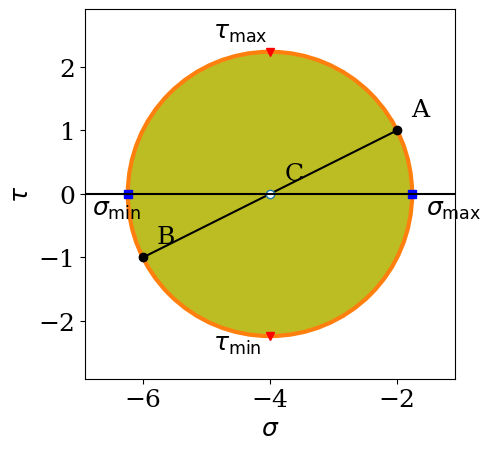


Analise no ref. S1: +1 MPa-------------------------
[-1.825 -6.175  0.52 ]
  Tensão normal mínima:  -6.236068
  Tensão normal máxima:  -1.763932
   Tensão normal média:  -4.000000
Tensão de corte mínima:  -2.236068
Tensão de corte máxima:  2.236068


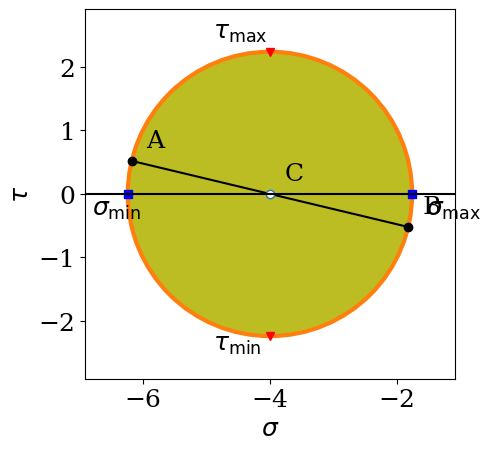


Analise no ref. S1: -1 MPa-------------------------
[-3.111 -4.889  2.052]
  Tensão normal mínima:  -6.236068
  Tensão normal máxima:  -1.763932
   Tensão normal média:  -4.000000
Tensão de corte mínima:  -2.236068
Tensão de corte máxima:  2.236068


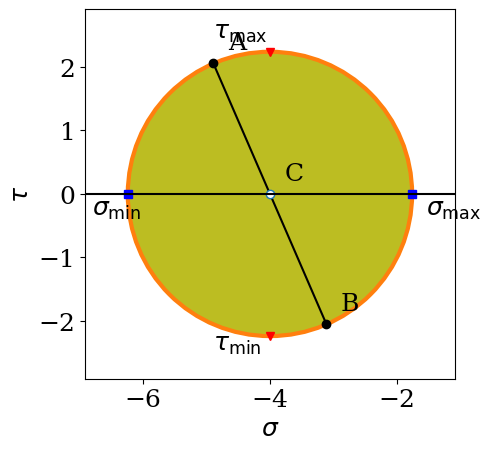

In [60]:
def mohr(S):
    S11 = S[0][0]
    S12 = S[0][1]
    S22 = S[1][1]
    center = [(S11 + S22)/2.0, 0.0]
    radius = np.sqrt((S11 - S22)**2/4.0 + S12**2)
    Smin = center[0] - radius
    Smax = center[0] + radius

    print("  Tensão normal mínima: ", '{:.6f}'.format(Smin))
    print("  Tensão normal máxima: ", '{:.6f}'.format(Smax))
    print("   Tensão normal média: ", '{:.6f}'.format(center[0]))
    print("Tensão de corte mínima: ", '{:.6f}'.format(-radius))
    print("Tensão de corte máxima: ", '{:.6f}'.format(radius))

    circ = plt.Circle((center[0],0), radius, facecolor='tab:olive', lw=3,
    edgecolor='tab:orange')
    desv = 0.1*radius
    plt.axis('image')
    ax = plt.gca()
    ax.add_artist(circ)
    ax.set_xlim(Smin - .3*radius, Smax + .3*radius)
    ax.set_ylim(-1.3*radius, 1.3*radius)
    plt.plot([S22, S11], [S12, -S12], 'ko')
    plt.plot([S22, S11], [S12, -S12], 'k')
    plt.plot(Smin, 0, 'bs')
    plt.plot(Smax, 0, 'bs')
    plt.plot(center[0], radius, 'rv')
    plt.plot(center[0], -radius, 'rv')
    plt.plot(center[0], center[1], 'o', mfc='w')
    plt.text(center[0]+desv, desv, 'C')
    plt.text(S22 + desv, S12 + desv , 'A')
    plt.text(S11 + desv, -S12 + desv, 'B')
    plt.text(Smin - 0.25*radius, -0.15*radius, r'$\sigma_\mathrm{min}$')
    plt.text(Smax + desv, -0.15*radius, r'$\sigma_\mathrm{max}$')
    plt.text(center[0]-4*desv, 1.1*radius, r'$\tau_\mathrm{max}$')
    plt.text(center[0]-4*desv, -1.1*radius, r'$\tau_\mathrm{min}$')
    plt.xlabel(r"$\sigma$", size=18)
    plt.ylabel(r"$\tau$", size=18)
    ax.axhline(y=0, color='k')
    ax.axvline(x=0, color='k')
    plt.show()

# Dados de entrada
print('Analise no ref. S0: -------------------------')
sxx = -6 # unit: MPa
syy = -2
txy = 1
print(mT2D(sxx,syy,txy))
mohr(np.array([[sxx, txy],[txy, syy]]))

print('\nAnalise no ref. S1: +1 MPa-------------------------')
# Dados no referencial das fibras
td = np.dot(T01,mT2D(sxx,syy,txy))
print(td)
mohr(np.array([[td[0], td[2]],[td[2], td[1]]]))

print('\nAnalise no ref. S1: -1 MPa-------------------------')
# Dados no referencial das fibras
td = np.dot(T01,mT2D(sxx,syy,-txy))
print(td)
mohr(np.array([[td[0], td[2]],[td[2], td[1]]]))

No espaço das tensões da circunferência de Mohr ($\sigma,\tau$) o ângulo entre o referêncial principal e o atual é dado por:

\begin{equation*}
\begin{aligned}
2\theta_{P1} &= \arctan \left(\frac{2\tau_{xz}}{\sigma_{xx}-\sigma_{zz}}\right) \\[1ex]
2\theta_{P2} &= 2\theta_{P1} + 2(90^\circ)\\
\end{aligned}
\end{equation*}

O ponto $I$ é obtido a partir do ponto $H$ a partir de uma rotação $2\theta$ em torno do ponto $C$. Esta rotação é no sentido do ponteiro dos relógios. Então, na realidade, o vetor de base $\vec{e}_\mathrm{I}$ obtém-se do vetor de base $\vec{e}_3$ por rotação de um ângulo $\theta$ e no sentido contrário ao do movimento dos ponteiros do relógio. O vetoer $\vec{e}_\mathrm{II}$ é perpendicular ao vetor de base $\vec{e}_\mathrm{I}$.

A matriz de transformação do referencial $O\vec{\imath}\,\vec{\jmath}\,\vec{k}$ para o referencial principal $O\vec{e}_\mathrm{I}\vec{e}_\mathrm{II}\vec{e}_\mathrm{III}$ vem:

\begin{equation*}
\begin{bmatrix}
\vec{e}_\mathrm{I} \\ \vec{e}_\mathrm{II} \\ \vec{e}_\mathrm{III}
\end{bmatrix} =
\begin{bmatrix}
\cos\theta_\mathrm{P} & \sin\theta_\mathrm{P} & 0\\
-\sin\theta_\mathrm{P} & \cos\theta_\mathrm{P} & 0\\
0 & 0 & 1 \\
\end{bmatrix}
\begin{bmatrix}
\vec{\imath}  \\ \vec{\jmath}  \\ \vec{k}
\end{bmatrix}
\end{equation*}

In [61]:
def angP(s11,s22,s12): return np.arctan((2*s12)/(s11-s22))

aP1 = angP(sxx,syy,txy)
aP2 = aP1 + np.pi

print('angulos das direções principais')
print('\nNo espaço das tensões:')
print('angPI:  ','{:.3f}'.format(np.rad2deg(aP1)),' deg | ','{:.3f}'.format(aP1),' radians')
print('angPII: ','{:.3f}'.format(np.rad2deg(aP2)),' deg | ','{:.3f}'.format(aP2),' radians')

aPI = aP1/2
aPII = aP2/2

print('\nNo espaço fisico:')
print('angPI:  ','{:.3f}'.format(np.rad2deg(aPI)),' deg | ','{:.3f}'.format(aPI),' radians')
print('angPII: ','{:.3f}'.format(np.rad2deg(aPII)),' deg | ','{:.3f}'.format(aPII),' radians')

def Q(ang,rot):
    c = np.cos(ang)
    s = np.sin(ang)
    if rot == 1:
        Qij = np.array([[1,0,0],[0,c,s],[0,-s,c]])
    elif rot == 2:
        Qij = np.array([[c,0,s],[0,1,0],[-s,0,c]])
    else:
        Qij = np.array([[c,s,0],[-s,c,0],[0,0,1]])
    return Qij

MatrTrans = Q(aPI,3)
print('\nMatriz de transformação = \n',MatrTrans)

print('\nVetores principais:')
nI = MatrTrans[0,:]
print('nI = ', nI)
nII = MatrTrans[1,:]
print('nII = ', nII)
nIII = MatrTrans[2,:]
print('nIII = ', nIII)

angulos das direções principais

No espaço das tensões:
angPI:   -26.565  deg |  -0.464  radians
angPII:  153.435  deg |  2.678  radians

No espaço fisico:
angPI:   -13.283  deg |  -0.232  radians
angPII:  76.717  deg |  1.339  radians

Matriz de transformação = 
 [[ 0.973 -0.23   0.   ]
 [ 0.23   0.973  0.   ]
 [ 0.     0.     1.   ]]

Vetores principais:
nI =  [ 0.973 -0.23   0.   ]
nII =  [0.23  0.973 0.   ]
nIII =  [0. 0. 1.]


---

Copyright (c) [Mecânica dos Sólidos I - DEMI - NOVA-SST]

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>
